In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table, vstack

In [4]:
injected = [
    "/data/hetdex/u/bgrashey/data_/injected_sources_log_bins.fits",
    "/data/hetdex/u/bgrashey/data_/injected_sources_2.fits",
    "/data/hetdex/u/bgrashey/data_/injected_sources_3.fits",
    "/data/hetdex/u/bgrashey/data_/injected_sources_4.fits",
    "/data/hetdex/u/bgrashey/data_/injected_sources_5.fits"
]

detected = [
    "/data/hetdex/u/bgrashey/data_/completeness_cat_01.fits",
    "/data/hetdex/u/bgrashey/data_/completeness_cat_02.fits",
    "/data/hetdex/u/bgrashey/data_/completeness_cat_03.fits",
    "/data/hetdex/u/bgrashey/data_/completeness_cat_04.fits",
    "/data/hetdex/u/bgrashey/data_/completeness_cat_05.fits"
]

In [5]:
for i in detected:
    t = Table.read(i)
    print(t[10000]["ra"])

334.41308743134294
334.41253195182657
334.42669864858726
334.4261430923855
334.41308743134294


In [6]:
from tools.functions import completeness_analysis, crossmatch

matched = []

for i in range(len(injected)):
    m = crossmatch(injected[i], detected[i])
    matched.append(m)

combined = vstack(matched)

In [6]:
#combined.write("./combined_completeness_table.fits", overwrite=False)
#combined

In [7]:
flux_bins = [
    (1.0000, 1.5849),
    (1.5849, 2.5119),
    (2.5119, 3.9811),
    (3.9811, 6.3096),
    (6.3096, 10.0000),
]

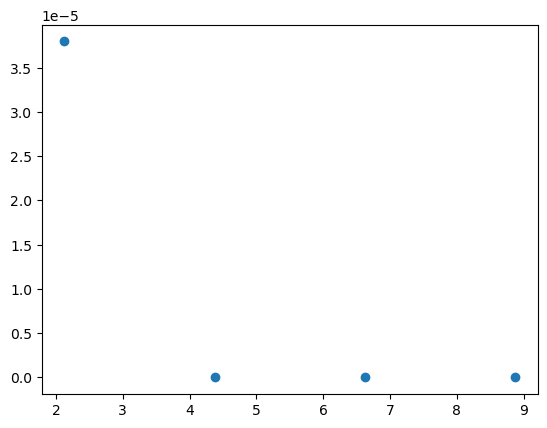

In [10]:
idx = "flux"


z_min, z_max = min(combined[idx]), max(combined[idx])
edges = np.linspace(z_min, z_max, 5)

z_bins = np.column_stack((edges[:-1], edges[1:]))

completeness = []
bin_centers = []

for bins in z_bins:
    valid = (combined[idx] > bins[0]) & (combined[idx] < bins[1])
    matched = combined[valid]["MATCHED"] == True
    missed = ~matched
    if valid.sum() == 0:
        c = np.nan
    else:
        c = matched.sum() / valid.sum()
    
    completeness.append(c)
    
    
    center = (bins[0] + bins[1]) / 2
    bin_centers.append(center)
    

plt.scatter(bin_centers, completeness)

In [ ]:
from tools.functions import fit_erf, completeness_model

popt = fit_erf(flux, completeness)

compl = completeness_model(flux, popt)

plt.scatter(flux, completeness, label="FoF")
plt.scatter(flux, completeness_cnn, label="CNN", color="r")

plt.plot(flux, compl, label="Completeness model")

plt.legend()
plt.ylabel("Completeness")
plt.xlabel("Flux in counts")
plt.xscale("log")
plt.show()

print(popt)

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table, vstack

inj = "/data/hetdex/u/bgrashey/data_/injected_matched_results.fits"
det = "/data/hetdex/u/bgrashey/data_/completeness_fof_catalog.fits"

from tools.functions import completeness_analysis, crossmatch

combined = crossmatch(inj, det)

Lade Cube: /data/hetdex/u/bgrashey/cubes/sn_cube.fits
  Shape: (1036, 2478, 2260)
  Erzeuge 10 Cutouts ...


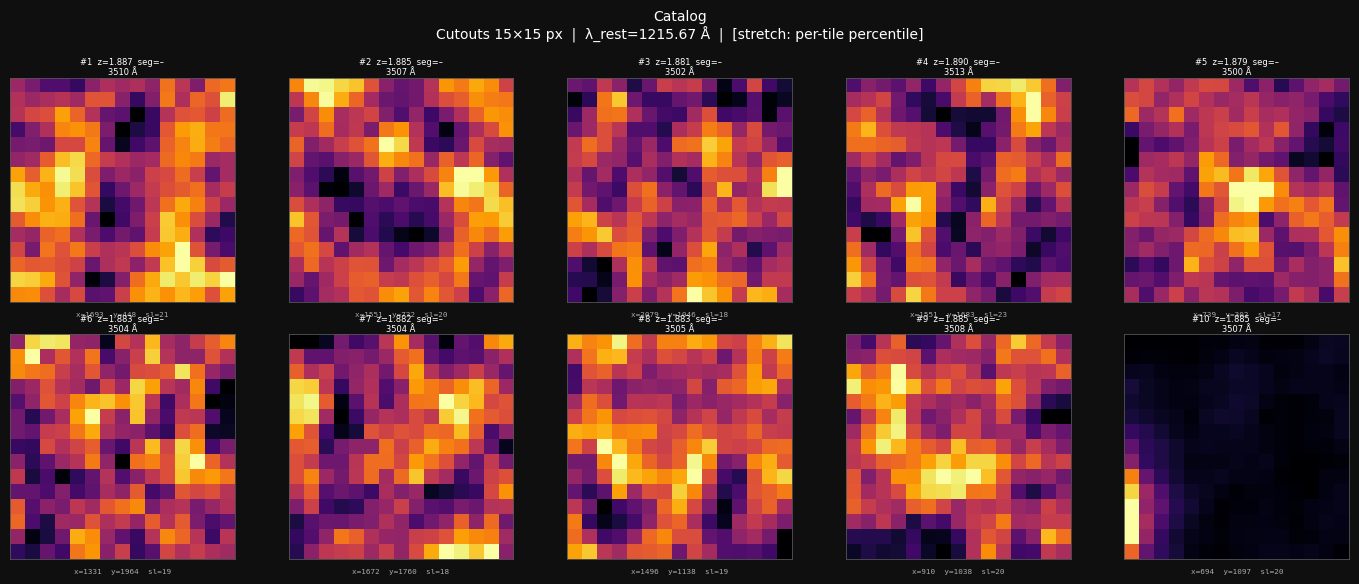

  Gespeichert: ./test_cutouts.pdf


In [33]:
from tools.functions import plot_cutout_grid
from astropy.table import Table

cube = "/data/hetdex/u/bgrashey/cubes/sn_cube.fits"
cat = Table.read("/data/hetdex/u/bgrashey/data_/injected_sources_log_bins.fits")

plot_cutout_grid(
     cat,
     cube,
     "./test_cutouts.pdf",
     cutout_size = 15,
     num_cutouts = 10,
    num_wave_slices=10,
     use_fixed_stretch = False,      
     vmin_fixed      = -0.5,
     vmax_fixed      =  0.5,
     cmap            = "inferno",
 )


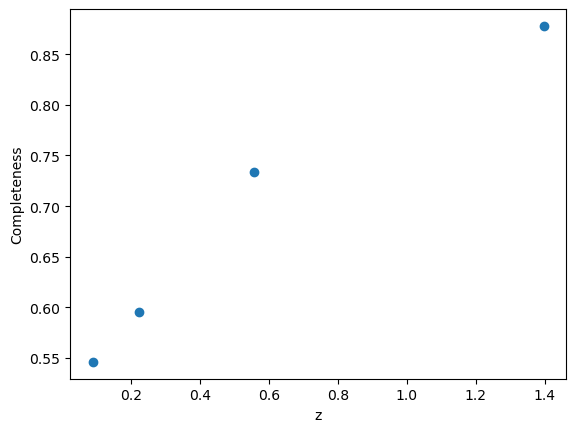

0.05001892723447602 1.9990905588081613


In [22]:
flux_bins = [
    (1.0000, 1.5849),
    (1.5849, 2.5119),
    (2.5119, 3.9811),
    (3.9811, 6.3096),
    (6.3096, 10.0000),
]

idx = "flux"

z_min, z_max = min(combined[idx]), max(combined[idx])
edges = np.logspace(np.log10(z_min), np.log10(z_max), 5)

z_bins = np.column_stack((edges[:-1], edges[1:]))

completeness = []
bin_centers = []

for bins in z_bins:
    valid = (combined[idx] > bins[0]) & (combined[idx] < bins[1])
    matched = combined[valid]["MATCHED"] == True
    missed = ~matched
    if valid.sum() == 0:
        c = np.nan
    else:
        c = matched.sum() / valid.sum()
    
    completeness.append(c)
    
    
    center = (bins[0] + bins[1]) / 2
    bin_centers.append(center)
    

plt.scatter(bin_centers, np.array(completeness) + 0.4)
plt.ylabel("Completeness")
plt.xlabel("z")
plt.show()
print(z_min, z_max)

In [3]:
mask = combined["MATCHED"] == False

print(mask.sum())

3782
